<a href="https://colab.research.google.com/github/Amnahyb4/W4-DL/blob/week4-deep-learning/DAY5/WeeklyProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weekly Project: Image Classification with Transfer Learning

In this project, you will build a complete image classification pipeline using transfer learning. You'll work with the dataset provided by your instructor.

**Learning Objectives:**
- Load and prepare image datasets for deep learning
- Use pre-trained models for transfer learning
- Implement two transfer learning strategies: fine-tuning and feature extraction
- Evaluate model performance
- Deploy models using ONNX for production (Optional)

**References:**

- [Training with PyTorch](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html)
- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

## Table of Contents

1. [Data Ingestion](#1)
2. [Data Preparation](#2)
3. [Model Building](#3)
4. [Training](#4)
   - [4.1 ConvNet as Fixed Feature Extractor](#4-1)
   - [4.2 Fine-tuning the ConvNet](#4-2)
5. [Evaluation](#5)
6. [Inference on Custom Images](#6)
7. [Deployment (ONNX)](#7)

## Imports

In [61]:
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler


In [2]:
!pip install dlai_grader

In [3]:
import helper_utils

## Setup Device

**Note: you will need a GPU; so please run this on Colab and specify a GPU runtime (e.g., T4-GPU)**

In [4]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


<a name='1'></a>
## 1. Data Ingestion

**Task**: The dataset should be downloaded and extracted to a local directory.

**References:**

- [Dataset and DataLoader](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html#dataset-and-dataloader)
- [torchvision.datasets.ImageFolder](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html)

In [9]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!cat ~/.kaggle/kaggle.json





{"username":"amnahyb","key":"1fd9debbf070f2c957a5ea3223e43591"}

In [10]:
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 87% 300M/346M [00:05<00:01, 48.5MB/s]
100% 346M/346M [00:05<00:00, 63.9MB/s]


In [11]:
!unzip -q intel-image-classification.zip
!ls


helper_utils.py			kaggle.json  sample_data  seg_test
intel-image-classification.zip	__pycache__  seg_pred	  seg_train


**Task**: create a `train_dataset` and `test_dataset` (without transforms for now).

In [12]:
pip install torch torchvision


In [13]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(root='seg_train/seg_train')
test_dataset = ImageFolder(root='seg_test/seg_test')


**Quick Check**: verify the counts of both train and test sets, match what's in the original source (Kaggle).

In [14]:
print("Train Classes:", train_dataset.classes)
print("Test Classes:", test_dataset.classes)

print("Number of training image:", len(train_dataset))
print("Number of testing image:", len(test_dataset))


Train Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Test Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of training image: 14034
Number of testing image: 3000


<a name='2'></a>
## 2. Data Preparation

Before training, we need to:
1. Define augmentation for training
2. Define normalization for both training and testing
3. Create **`DataLoader`** for efficient batch processing

**Task:** Create transformation pipelines for training and validation. Pre-trained models expect ImageNet normalization statistics.

**Reference:**

- [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html)

In [80]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

In [81]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(root='seg_train/seg_train', transform=train_transforms)
test_dataset = ImageFolder(root='seg_test/seg_test', transform=test_transforms)

In [82]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels=next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


**Quick Check**: Visualize a batch of training images

In [83]:
helper_utils.visualize_batch?

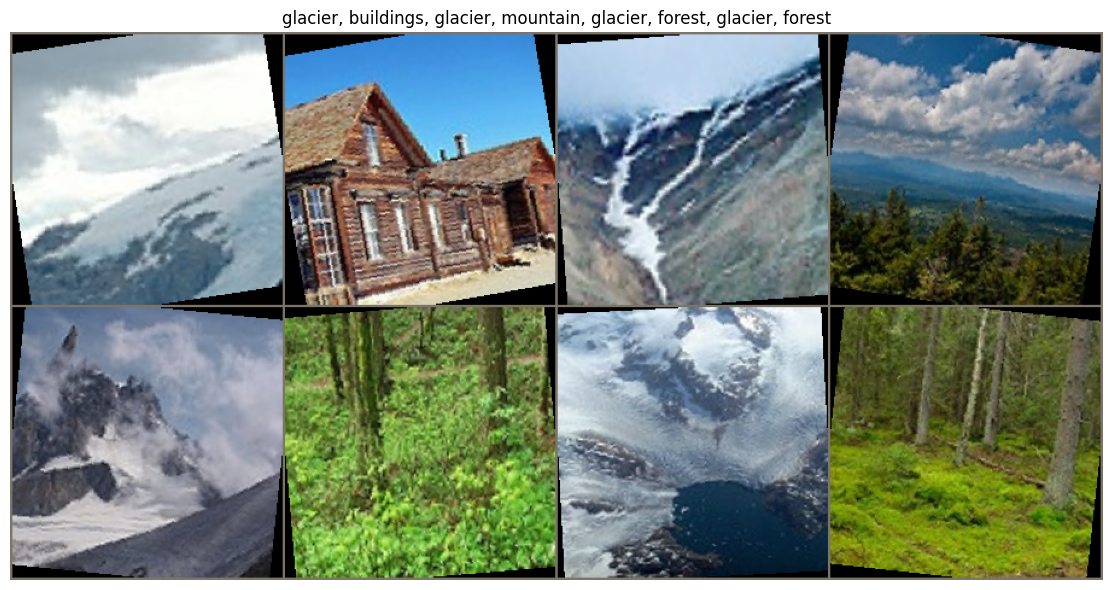

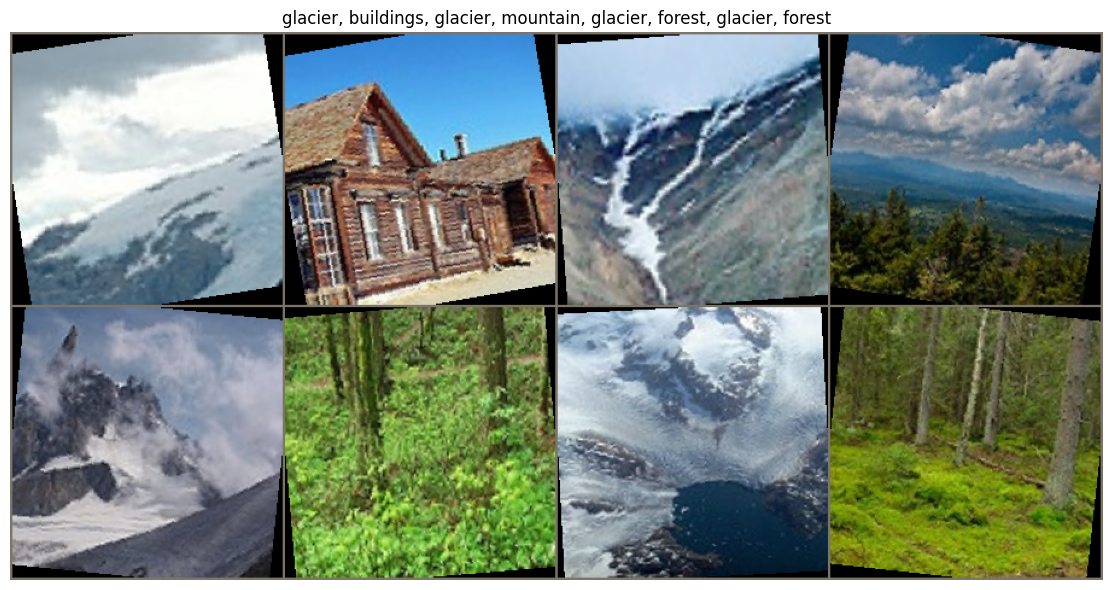

In [84]:
helper_utils.visualize_batch(train_loader, class_names=train_dataset.classes)


<a name='3'></a>
## 3. Model Building

We'll use a pre-trained ResNet-18 model and adapt it for our 6-class classification task.

**Task:** Load a pre-trained ResNet-18 model and modify the final layer for 6 classes.

**Reference:**

- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
- [torchvision.models](https://pytorch.org/vision/stable/models.html)
- [ResNet documentation](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)

In [85]:
import torchvision.models as models

model = models.resnet18(pretrained=True)

#replace final layer (imgnet=1000 woth out 6 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 6)

model = model.to(device)



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<a name='4'></a>
## 4. Training

**Task:** Implement a training **function** and then train using two different transfer learning strategies.

**Reference:** [PyTorch Training Tutorial](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html#the-training-loop)

In [86]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device,
                epochs=5, scheduler=None):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total if total > 0 else 0.0
        train_acc  = correct / total if total > 0 else 0.0

        # ---- Validation ----
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * labels.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total if val_total > 0 else 0.0
        val_acc  = val_correct / val_total if val_total > 0 else 0.0

        # ---- Scheduler step (PyTorch tutorial style) ----
        if scheduler is not None:
            scheduler.step()

        # ---- Save history ----
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} Test Acc: {val_acc:.4f}")

    return history



<a name='4-1'></a>
### 4.1 ConvNet as Fixed Feature Extractor

In this approach, we freeze all the convolutional layers and only train the final classifier layer.

**Task:**

1. Load a fresh pre-trained model
2. Freeze all parameters except the final layer
3. Set up optimizer to only train the final layer
4. Train the model

In [87]:
classes= train_dataset.classes
num_classes=len(classes)

model_conv=models.resnet18(pretrained=True)
model_conv.fc = nn.Linear(model_conv.fc.in_features, num_classes)
model_conv = model_conv.to(device)

In [88]:
for parms in model_conv.parameters(): #frozen
    parms.requires_grad = False

for parms in model_conv.fc.parameters(): #unfreeze claasification layer
    parms.requires_grad = True

In [90]:

optimizer_conv = optim.SGD(model_conv.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [91]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()


In [92]:
history_conv = train_model(
    model_conv, train_loader, test_loader, criterion, optimizer_conv, device,
    epochs=5, scheduler=exp_lr_scheduler
)

Epoch [1/5] Loss: 0.7458 Train Acc: 0.7366 Test Acc: 0.8630
Epoch [2/5] Loss: 0.5326 Train Acc: 0.8070 Test Acc: 0.8863
Epoch [3/5] Loss: 0.5075 Train Acc: 0.8124 Test Acc: 0.8850
Epoch [4/5] Loss: 0.4902 Train Acc: 0.8172 Test Acc: 0.8917
Epoch [5/5] Loss: 0.4889 Train Acc: 0.8190 Test Acc: 0.8803


In [93]:
import matplotlib.pyplot as plt


**Quick Check**: Visualize training history

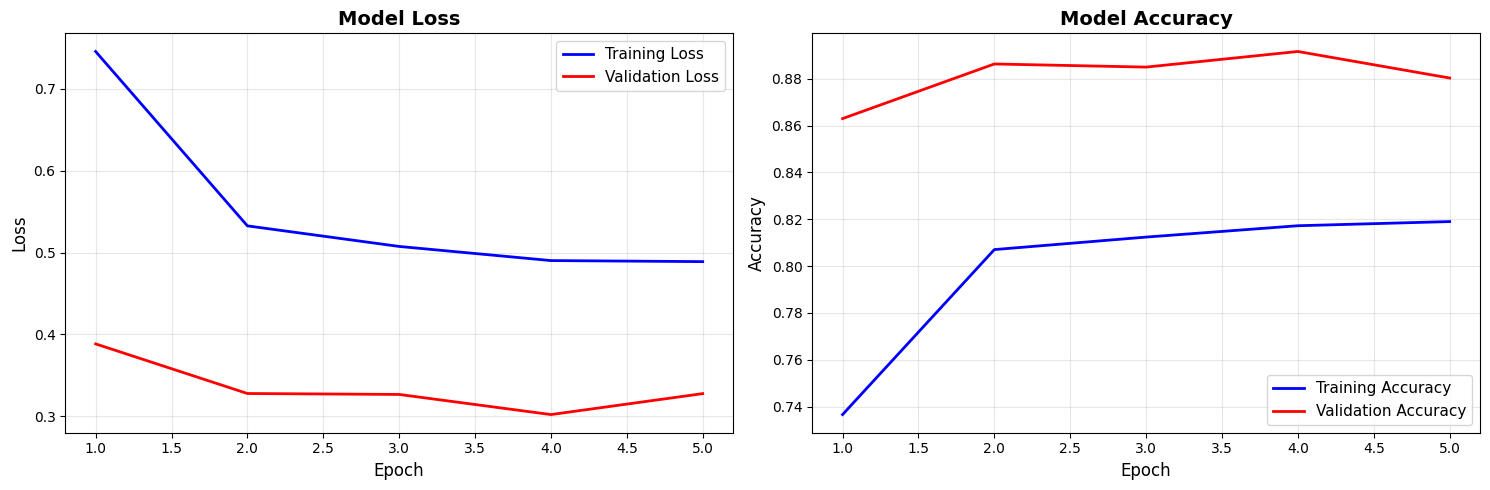

In [94]:
helper_utils.visualize_training_history(history_conv)
plt.show()

**Quick Check**: Visualize predictions

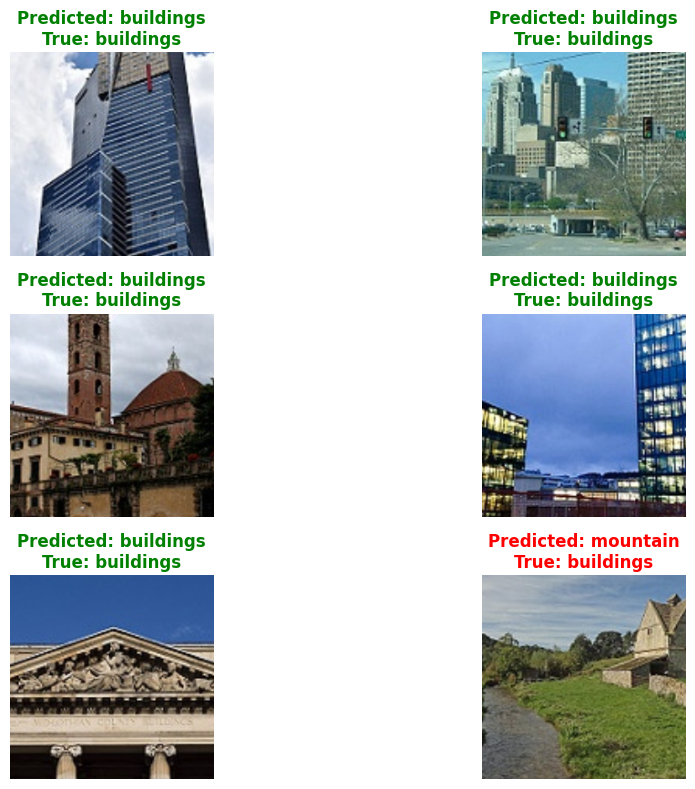

In [95]:
helper_utils.visualize_predictions(model_conv, test_loader, classes, device, num_images=6)
plt.show()

<a name='4-2'></a>
### 4.2 Fine-tuning the ConvNet

In this approach, we unfreeze all layers and train the entire network with a smaller learning rate.

**Task:**

1. Load a fresh pre-trained model
2. Modify the final layer
3. Set up optimizer for all parameters with a smaller learning rate
4. Train the model

In [96]:
model_ft = models.resnet18(pretrained=True)

model_ft.fc = nn.Linear(model_ft.fc.in_features, num_classes)
model_ft = model_ft.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [97]:
for p in model_ft.parameters():
    p.requires_grad = True

In [98]:
from torch.optim import lr_scheduler

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


In [99]:
history_ft = train_model(
    model_ft, train_loader, test_loader, criterion, optimizer_ft, device,
    epochs=5, scheduler=exp_lr_scheduler
)

Epoch [1/5] Loss: 0.5315 Train Acc: 0.8067 Test Acc: 0.9197
Epoch [2/5] Loss: 0.3655 Train Acc: 0.8681 Test Acc: 0.9207
Epoch [3/5] Loss: 0.3337 Train Acc: 0.8787 Test Acc: 0.9227
Epoch [4/5] Loss: 0.3064 Train Acc: 0.8895 Test Acc: 0.9287
Epoch [5/5] Loss: 0.3009 Train Acc: 0.8893 Test Acc: 0.9297


**Quick Check**: Visualize training history

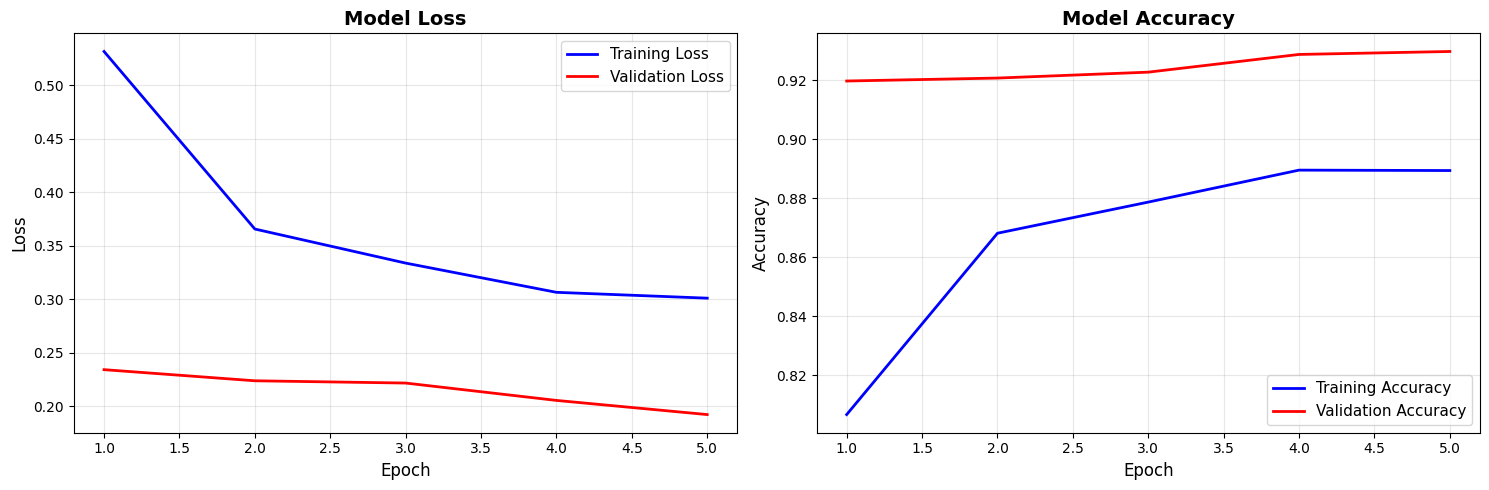

In [100]:
helper_utils.visualize_training_history(history_ft)
plt.show()

**Quick Check**: Visualize predictions

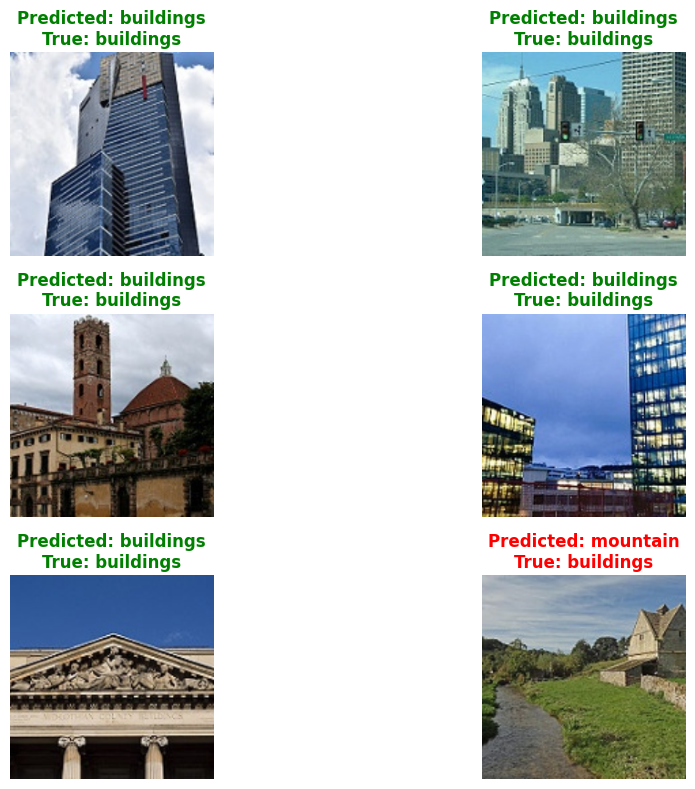

In [40]:
helper_utils.visualize_predictions(model_ft, test_loader, classes, device, num_images=6)
plt.show()

<a name='5'></a>
## 5. Evaluation

Compare the performance of both approaches.

**Task:** Evaluate both models and compare their performance metrics.

In [101]:
# Evaluate models on validation set
#your code
# Compare final validation accuracies, training times, etc.

# Print comparison
print("Feature Extractor Approach:")
print(f"  Best Val Accuracy: {max(history_conv['val_acc']):.4f}")
print(f"  Final Val Accuracy: {history_conv['val_acc'][-1]:.4f}")
print()
print("Fine-tuning Approach:")
print(f"  Best Val Accuracy: {max(history_ft['val_acc']):.4f}")
print(f"  Final Val Accuracy: {history_ft['val_acc'][-1]:.4f}")

Feature Extractor Approach:
  Best Val Accuracy: 0.8917
  Final Val Accuracy: 0.8803

Fine-tuning Approach:
  Best Val Accuracy: 0.9297
  Final Val Accuracy: 0.9297


<a name='6'></a>
## 6. Inference on Custom Images

Test your trained model on custom images.

**Task:** Load a custom image, preprocess it, and make a prediction using your trained model.

**Reference:** [Image Preprocessing](https://pytorch.org/vision/stable/transforms.html)

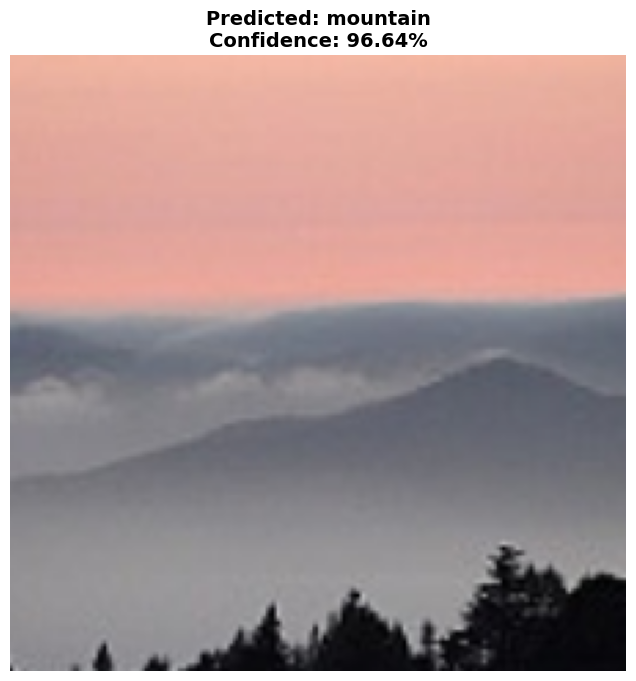

In [102]:
# Make prediction on a custom image
img_path = "/content/seg_pred/seg_pred/10047.jpg"

# YOUR CODE HERE
# Use helper_utils.visualize_single_prediction or helper_utils.predict_single_image
helper_utils.visualize_single_prediction(
    model_ft,
    img_path,
    test_transforms,
    classes,
    device
)
plt.show()


# 🏆🎉 Congratulations on completing the Weekly Final Project! 🎉🏆

Fantastic job on finishing the Weekly Final Project! You’ve put your skills to the test and made it to the end. Take a moment to celebrate your hard work and dedication. Keep up the great work and continue your learning journey!

<a name='7'></a>
## 7. Deployment (ONNX)

Convert your trained model to ONNX format for deployment.

**Task:**
1. Convert the PyTorch model to ONNX format
2. Load the ONNX model and perform inference

**Reference:**
- [PyTorch to ONNX](https://docs.pytorch.org/tutorials/beginner/onnx/export_simple_model_to_onnx_tutorial.html)

In [106]:
!pip -q install onnx onnxruntime onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 693.4/693.4 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 kB 9.7 MB/s eta 0:00:00


In [107]:
# Convert model to ONNX

model_ft.eval()

#Create dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Export to ONNX
onnx_path = "model_ft.onnx"

torch.onnx.export(
    model_ft,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=11
)

print(f"Model exported to {onnx_path}")


/tmp/ipython-input-836121916.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0108 17:30:01.587000 536 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 40 of general pattern rewrite rules.
Model exported to model_ft.onnx


In [104]:
!pip install onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00


In [110]:
# Load ONNX model and perform inference
import onnxruntime as ort
import numpy as np
from PIL import Image

ort_session = ort.InferenceSession("model_ft.onnx")

img_path = "/content/seg_pred/seg_pred/10048.jpg" # change image name if needed
img = Image.open(img_path).convert("RGB")

img_tensor = test_transforms(img).unsqueeze(0)  # (1, 3, 224, 224)

img_numpy = img_tensor.cpu().numpy()

outputs = ort_session.run(None, {"input": img_numpy})

predictions = outputs[0]
pred_class_idx = np.argmax(predictions)
pred_class = classes[pred_class_idx]
confidence = np.max(predictions)

print(f"Predicted class: {pred_class}")
print(f"Confidence: {confidence:.4f}")


Predicted class: buildings
Confidence: 5.8770
